In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal,Annotated
from pydantic import BaseModel,Field
import operator

In [3]:
import os
import requests
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage,HumanMessage

In [4]:
load_dotenv(override=True)

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

generator_llm = ChatOpenAI(
    model_name="gpt-4o-mini",
    temperature=0,
    openai_api_key=OPENAI_API_KEY)

evaluator_llm = ChatOpenAI(
    model_name="gpt-4o-mini",
    temperature=0,
    openai_api_key=OPENAI_API_KEY)

optimizer_llm = ChatOpenAI(
    model_name="gpt-4o-mini",
    temperature=0,
    openai_api_key=OPENAI_API_KEY)

In [5]:
class PostEvaluationSchema(BaseModel):
    evaluation: Literal["approved","needs_improvement"] = Field(...,description="Final evaluation result")
    feedback:str = Field(...,description="feedback for the Facebook post.")
    

structured_evaluator_llm = evaluator_llm.with_structured_output(PostEvaluationSchema)


In [6]:
class PostState(TypedDict):
    topic: str    
    post: str
    evaluation: Literal["approved","needs_improvement"]    
    feedback: str
    iteration: int
    max_iteration: int

    post_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [7]:
def generate_post(state: PostState) -> dict:
    """Find the sentiment of the review."""
    topic = state["topic"]
    messages = [
        SystemMessage(content="You are a funny and clever Facebook influencer."),
        HumanMessage(content=f"""
        Write a short, original and hilarious Facebook post on the topic: {topic}.

        Rules:
        - Do NOT use question-answer format
        - Max 500 characters
        - Use observational humor, irony, sarcasm or cultural reference
        - Think in meme logic, punchlines or relatble takes
        - Use simple, day to day english
        """)
    ]
    
    response = generator_llm.invoke(messages).content
    return {"post":response,"post_history":[response]}

In [8]:
def evaluate_post(state: PostState) -> dict:
    """Find the sentiment of the review."""
    
    messages = [
        SystemMessage(content="""You are a ruthless, no-laugh-given Facebook critic. 
        You evaluate posts based on humor, originality, virality, and post format."""),
        HumanMessage(content=f"""
        Evaluate the following Facebook post:

        Post: "{state['post']}"

        Use the criteria below to evaluate the post:

        1. Originality – Is this fresh, or have you seen it a hundred times before?  
        2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
        3. Punchiness – Is it short, sharp, and scroll-stopping?  
        4. Virality Potential – Would people share, react, or comment on it?  
        5. Format – Is it a well-formed Facebook post 
        (not a setup-punchline joke, not a Q&A joke, and under 500 characters)?

        Auto-reject if:
        - It's written in question-answer format 
        (e.g., "Why did..." or "What happens when...")
        - It exceeds 500 characters
        - It reads like a traditional setup-punchline joke
        - Dont end with generic, throwaway, or deflating lines that weaken 
        the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

        ### Respond ONLY in structured format:
        - evaluation: "approved" or "needs_improvement"  
        - feedback: One paragraph explaining the strengths and weaknesses 
        """)
    ]
    
    response = structured_evaluator_llm.invoke(messages)
    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [9]:
def optimize_post(state: PostState) -> dict:
    """Find the sentiment of the review."""
    
    messages = [
        SystemMessage(content="""You punch up Facebook posts for 
        virality and humor based on given feedback."""),
        HumanMessage(content=f"""
        Improve the Facebook post based on this feedback:
        "{state['feedback']}"

        Topic: "{state['topic']}"
        Original Post:
        {state['post']}

        Re-write it as a short, viral-worthy Facebook post. 
        Avoid Q&A style and stay under 500 characters.
        """)
    ]
    
    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'post': response, 'iteration': iteration, 'post_history': [response]}

In [10]:
def route_evaluation(state:PostState)-> Literal["approved","needs_improvement"]:
    # Mirros the conditional routing based on the descriminant in the original
    if state["evaluation"] == "needs_improvement" or state["iteration"] >= state["max_iteration"]:
        return "approved"
    else:
        return "needs_improvement"
    

In [11]:
graph = StateGraph(PostState)

In [12]:
graph.add_node("generate_post",generate_post)
graph.add_node("evaluate_post",evaluate_post)
graph.add_node("optimize_post",optimize_post)



In [13]:
graph.add_edge(START,"generate_post")
graph.add_edge("generate_post","evaluate_post")
graph.add_conditional_edges(
    "evaluate_post",
    route_evaluation,
    {"approved": END, "needs_improvement" : "optimize_post"})
graph.add_edge("optimize_post","evaluate_post")

In [14]:
workflow = graph.compile()

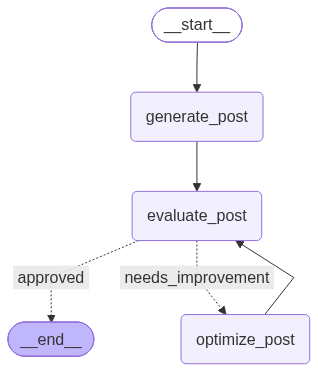

In [15]:
workflow

In [16]:
initial_state = {
    "topic":"Wife",
    "iteration": 1,
    "max_iteration": 5
}

In [17]:
# initial_state = {
#     "review":"Application fails whenever i try to open in on my desktop mozilla browser, its fails always.",
# }

In [18]:
workflow.invoke(initial_state)

{'topic': 'Wife',
 'post': 'My wife just told me to stop impersonating a flamingo. I had to put my foot down! 🦩 I thought we were having a blast until she Googled “how to get rid of a husband.” Apparently, her idea of romance is me silently watching her binge Netflix. Who knew “till death do us part” really meant “till Netflix do us part”? At least I’m still the king of the remote… for now! 👑📺 #MarriageGoals #FlamingoFail #RemoteControlRoyalty #NetflixAndNope #HusbandLife #ComedyCouple',
 'evaluation': 'approved',
 'feedback': "This post showcases a good level of originality with a unique twist on the classic marriage humor trope. The humor is relatable and clever, particularly the play on words with 'put my foot down' and the Netflix reference, which many can connect with. The punchiness is decent, as it maintains a good flow without dragging on, and the use of emojis adds a light-hearted touch. The post is well-structured and fits within the character limit, making it suitable for Fa